# GROUP 3 CODE, DOCUMENTATION AND THOUGHT PROCESS
## Setting Up
To begin place the CSV file that would like to be queried in the same folder as this notebook and change the name between the '' to the name of the file. Also the files called pdf_paula.py and key_word_documnet_retiever must be uploaded to the notebook when prompted as these contain code that will be needed later.

For example if the files name was Default.CSV the code should read as;
    pd.read_csv('Default.CSV', sep=";", header=None).


###Also, if google drive is not being used remove the following code;

from google.colab import drive

drive.mount('/content/drive')



In [ ]:
import pandas as pd
import os
from google.colab import drive
from google.colab import files
src = list(files.upload().values())[0]
open('pdf_paula.py','wb').write(src)
from pdf_paula import pdf_extraction
src2 = list(files.upload().values())[0]
open('key_word_document_retriever.py','wb').write(src)
from key_word_document_retriever import key_word_document_retriever

!pip install pypdf2
!pip install textract

drive.mount('/content/drive')
df = pd.read_csv("drive/My Drive/SDG7/2018_WoS.csv", sep=";", header=None)

Saving pdf_paula.py to pdf_paula (9).py


Saving key_word_document_retriever.py to key_word_document_retriever (1).py
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Previewing your data
Below is a preview of the start and end of the data found in the uploaded CSV

In [ ]:
df.head()

,0,1,2,3
0,405496000001,COMMUNICATIONS IN NONLINEAR SCIENCE AND NUMERI...,Research on the reliability of friction system...,"In this paper, the reliability of a non-linear..."
1,405496000002,COMMUNICATIONS IN NONLINEAR SCIENCE AND NUMERI...,Vector solitons in coupled nonlinear Schroding...,The dynamics of two-component solitons is stud...
2,405496000003,COMMUNICATIONS IN NONLINEAR SCIENCE AND NUMERI...,Analysis of cyclical behavior in time series o...,In this paper we have analyzed scaling propert...
3,405496000004,COMMUNICATIONS IN NONLINEAR SCIENCE AND NUMERI...,Impact of marine reserve on maximum sustainabl...,Multispecies fisheries management requires man...
4,405496000005,COMMUNICATIONS IN NONLINEAR SCIENCE AND NUMERI...,Double-well chimeras in 2D lattice of chaotic ...,We investigate spatio-temporal dynamics of a 2...


In [ ]:
df.tail()

,0,1,2,3
1630345,501568200001,TURKISH JOURNAL OF BIOCHEMISTRY-TURK BIYOKIMYA...,"TBS International Biochemistry Congress 2018, ...",NaN
1630346,502087800001,JOURNAL OF GASTROINTESTINAL AND LIVER DISEASES,The 5th Romanian-German Symposium of Gastroent...,NaN
1630347,502088600001,JOURNAL OF GASTROINTESTINAL AND LIVER DISEASES,The XXXVIIIth National Congress of Gastroenter...,NaN
1630348,502089100001,JOURNAL OF GASTROINTESTINAL AND LIVER DISEASES,The 10th National Symposium on Inflammatory Bo...,NaN
1630349,502648200001,JOURNAL OF PORPHYRINS AND PHTHALOCYANINES,Electrochemistry of zinc tetraarylporphyrins c...,Two series of zinc tetraarylporphyrins contain...


## Checking Compatability
In order for the program to function correctly the data must be of a particular format of 4 columns with the labels for each being Publication_Code , Journal_Name, Title and Abstract. Below the shape of the data is checked, if the second numebr is '4' it means that the data has the correct number of columns. IF this is not the case try to edit the data to either add or remove  columns.

In [ ]:
df.shape

(1630350, 4)

If the number of columns is correct it is now time to address the column headings. If these are not already correctly label, as stated above, please run the following code. This should apply the correct headings to the data and give a preview where you can check the table has been labelled correctly. If the labels have been labelled in an incorrect order the order can be changed in the code below. This is by rearranging the labels into the correct order e.g. from ['Publication_Code','Journal_Name', 'Title', 'Abstract'] to ['Abstract', 'Publication_Code','Journal_Name', 'Title'].

In [ ]:
df.columns = ['Publication_Code','Journal_Name', 'Title', 'Abstract']
print(df.head())
print(df.tail())

   Publication_Code  ...                                           Abstract
0      405496000001  ...  In this paper, the reliability of a non-linear...
1      405496000002  ...  The dynamics of two-component solitons is stud...
2      405496000003  ...  In this paper we have analyzed scaling propert...
3      405496000004  ...  Multispecies fisheries management requires man...
4      405496000005  ...  We investigate spatio-temporal dynamics of a 2...

[5 rows x 4 columns]
         Publication_Code  ...                                           Abstract
1630345      501568200001  ...                                                NaN
1630346      502087800001  ...                                                NaN
1630347      502088600001  ...                                                NaN
1630348      502089100001  ...                                                NaN
1630349      502648200001  ...  Two series of zinc tetraarylporphyrins contain...

[5 rows x 4 columns]


## Preprocessing Data will be Needed
From the above preview we can see that there are many NaNs, the number of which is given in the code below, which will have to be removed later by preprocessing.

In [ ]:
df.isna().sum()

Publication_Code        0
Journal_Name            0
Title                   0
Abstract            34492
dtype: int64

## Breaking Down the Data
The following code disects any given data by finding all available journal names and places them in to a list before giving them back.After being given some key words the following algorithm can then find journal names that contain the key words. 


In [ ]:
import numpy as np
import nltk 

chosen_idx = np.random.choice(1000, replace=False, size=50)
sample_df = df.iloc[chosen_idx]

journal_names = df.Journal_Name.unique()

j_list = journal_names.tolist()
print("All Journal Names")
print(j_list)

key_words = ['sustainable', 'sustainibility', 'renewable']

key_journals = []

for line in j_list:
    tmp = line.split()
    for word in key_words:
        for w in tmp:
            if w.lower()==word.lower():
                tmp1 = w
                tmp2 = tmp
                key_journals.append([tmp1, tmp2])
print(f'There are {len(key_journals)} journals using key words: {[i for i in key_words]}')

All Journal Names
['COMMUNICATIONS IN NONLINEAR SCIENCE AND NUMERICAL SIMULATION', 'IEEE JOURNAL OF SELECTED TOPICS IN QUANTUM ELECTRONICS', 'JOURNAL OF CIRCUITS SYSTEMS AND COMPUTERS', 'BERNOULLI', 'FOOD CHEMISTRY', 'SCIENCE CHINA-INFORMATION SCIENCES', 'FOOD HYDROCOLLOIDS', 'JOURNAL OF CELLULAR AUTOMATA', 'NURSING HISTORY REVIEW', 'JOURNAL OF APPLIED POLYMER SCIENCE', 'MEASUREMENT', 'RECORDS OF NATURAL PRODUCTS', 'JOURNAL OF CELLULAR PHYSIOLOGY', 'BIOINTERPHASES', 'SCIENCE OF THE TOTAL ENVIRONMENT', 'INTERNATIONAL JOURNAL OF COMPUTATIONAL METHODS', 'COMPUTER SPEECH AND LANGUAGE', 'JOURNAL OF COMBINATORIAL THEORY SERIES A', 'MATHEMATICAL BIOSCIENCES AND ENGINEERING', 'LEUKEMIA & LYMPHOMA', 'JOURNAL OF MATHEMATICAL ANALYSIS AND APPLICATIONS', 'INTERNATIONAL JOURNAL OF AUTOMOTIVE TECHNOLOGY', 'INFORMATION FUSION', '2D MATERIALS', 'JOURNAL OF FOOD ENGINEERING', 'JOURNAL OF HAZARDOUS MATERIALS', 'POSTHARVEST BIOLOGY AND TECHNOLOGY', 'DISCRETE AND CONTINUOUS DYNAMICAL SYSTEMS', 'IEEE TRANS

## Extracting Key Journals by their Abstracts
In order to get the key journal's more accurately the following code will be used to get imporatnt files their abstracts instead of just their names. To begin the key terms must firstly be generated which is an improvement over the above where they had to be manually found and entered.
This is done by placing a folder containing many relevant pdf documents in the same directory as the note book. This address can be changed below from the default to another folder when working on data that differs from the default. To do so is the same process as previously when changing the uploaded data.

A list of pdfs should then be given.

In [ ]:
# use glob lib to get fileNames
import glob
fileNames = glob.glob("drive/My Drive/SDG7/PDFs/*.pdf") #gets all pdf documents in given directory 

# create pdf extraction object and initialise with fileNames
pdf_obj = pdf_extraction(fileNames)

# get pdfs as a list of lists (that contains each pdf doc as a long string)
mypdfs = pdf_obj.get_pdfs_as_text()

# print results of our pdf files
mypdfs

[[' \n \n \n \n  \nThe 2\n-\npagers do not reflect any GRI position but are recommend\nations by UN Global Compact and the WBCSD\n \nEnsure access to affordable, reliable, sustainable, \nand modern energy for all\n \n \n \n \n \nThe role of business\n \nModern society depends on reliable and affordable energy services to function smoothly and to develop equitably. A well\n-\nestablished \nenergy system supports all sectors from medicine and education to agriculture, infrastructure, communications and high\n-\ntechn\nology. \nIntensive development patterns have historically relied on inexpensive and energy\n-\ndense fossil fuels, which also happen to be the \nprimary source of greenhouse gas emissions contributing to climate change. However, new, clean technologies are availab\nle that can \nreorient development along a more sustainable trajectory. \n \nBusiness can accelerate the transition to an affordable, reliable and sustainable energy system by investing in renewable ene\nrgy \nre

## Preprocessing the PDFs
As seen above preprocessing the PDFS is needed in order to get rid of erroneous text/chars such as stopwords and random characters. The following code shall sequentially go through and split every word into its own string and remove any that are seen as erroneous. All the strings that are left shall be outputted and the number of pdfs given.

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
import string
nltk.download('stopwords')
nltk.download('punkt')

def get_tokens(text):
    all_stopwords = stopwords.words('english')
    punc = string.punctuation
    word_toks = word_tokenize(text)
    tokens_without_sw = [word for word in word_toks if not word in all_stopwords]
    tokens_without_punc = [word for word in tokens_without_sw if not word in punc]
    tokens_lower = [word.lower() for word in tokens_without_punc]
    tokens_no_nums = [word for word in tokens_lower if word.isalpha()]
    return tokens_no_nums


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
pdf_data_list_of_strings = []
for i, pdf in enumerate(mypdfs):
    pdf_data_list_of_strings.append(get_tokens(mypdfs[i][0]))
pdf_data_list_of_strings

[['the',
  'pagers',
  'reflect',
  'gri',
  'position',
  'recommend',
  'ations',
  'un',
  'global',
  'compact',
  'wbcsd',
  'ensure',
  'access',
  'affordable',
  'reliable',
  'sustainable',
  'modern',
  'energy',
  'the',
  'role',
  'business',
  'modern',
  'society',
  'depends',
  'reliable',
  'affordable',
  'energy',
  'services',
  'function',
  'smoothly',
  'develop',
  'equitably',
  'a',
  'well',
  'established',
  'energy',
  'system',
  'supports',
  'sectors',
  'medicine',
  'education',
  'agriculture',
  'infrastructure',
  'communications',
  'high',
  'techn',
  'ology',
  'intensive',
  'development',
  'patterns',
  'historically',
  'relied',
  'inexpensive',
  'energy',
  'dense',
  'fossil',
  'fuels',
  'also',
  'happen',
  'primary',
  'source',
  'greenhouse',
  'gas',
  'emissions',
  'contributing',
  'climate',
  'change',
  'however',
  'new',
  'clean',
  'technologies',
  'availab',
  'le',
  'reorient',
  'development',
  'along',
  'susta

In [ ]:
len(pdf_data_list_of_strings)

7

## TF-IDF Values is the Future
Now the text has been cleaned of erroneous strings it can now be used to calculate the TF-IDF values of each string. This will be useful to see what key words are the most important across all documents by giving them a weight according to the frequency that they appear across a document when compared to the other documents.
The TF-IDF values per word is then given below in a table.

In [ ]:
# import detokeniser
from nltk.tokenize.treebank import TreebankWordDetokenizer

# reassign 'mypdfs' variable to detokenised string lists
mypdfs = [TreebankWordDetokenizer().detokenize(lst) for lst in pdf_data_list_of_strings]

doc_ret_obj = key_word_document_retriever(mypdfs)
mat, word = doc_ret_obj.get_tfidf()

df_tfidf_pdfs = pd.DataFrame(mat, columns=word)
df_tfidf_pdfs

,ability,able,absence,accelerate,accepted,access,accessible,accordance,according,accordingly,account,accounts,accuracy,accurate,achieve,across,actions,active,activities,activity,actually,ad,adair,adapted,add,added,addition,additional,addressed,addresses,addressing,adequate,adequately,adily,adjustments,administrations,adopted,adopting,adoption,advanced,...,volumes,washington,waste,water,watts,wave,wbcsd,weakness,webpage,weighted,weights,well,what,whe,where,whether,while,who,whole,whs,wi,wide,wind,with,within,without,wolf,women,wood,working,workshops,world,would,xisting,year,yearbook,yearbooks,years,yield,ype
0,0.000000,0.000000,0.000000,0.038241,0.000000,0.080127,0.038241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018165,0.038241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027133,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027133,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076483,0.000000,0.000000,0.000000,0.000000,0.027133,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031744,0.000000,0.000000,0.063487,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016025,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.034263,0.000000,0.016352,0.000000,0.000000,0.013574,0.016352,0.000000,0.000000,0.000000,0.007768,0.000000,0.016352,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016352,0.000000,0.000000,0.040721,0.000000,0.000000,0.000000,0.000000,0.000000,0.016352,0.013574,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.013574,0.013574,0.000000,0.016352,0.000000,0.000000,0.000000,0.000000,0.000000,0.016352,0.011602,0.000000,0.000000,0.000000,0.016352,0.000000,0.016352,0.020147,0.034807,0.011602,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.065409,0.052944,0.000000,0.000000,0.143904,0.016352,0.016352,0.020147,0.000000,0.000000
2,0.000000,0.006504,0.000000,0.000000,0.000000,0.085866,0.000000,0.000000,0.008552,0.012053,0.000000,0.000000,0.000000,0.000000,0.012053,0.017176,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.024106,0.000000,0.000000,0.010005,0.024106,0.000000,0.008552,0.000000,0.012053,0.000000,0.012053,0.000000,0.000000,0.000000,0.000000,0.036159,0.000000,0.008552,...,0.000000,0.000000,0.000000,0.020010,0.000000,0.000000,0.000000,0.000000,0.000000,0.010005,0.000000,0.017104,0.012053,0.000000,0.008552,0.000000,0.010005,0.205248,0.000000,0.020010,0.000000,0.000000,0.000000,0.008552,0.000000,0.010005,0.012053,0.020010,0.04002,0.020010,0.000000,0.045528,0.000000,0.012053,0.010102,0.000000,0.000000,0.000000,0.012053,0.012053
3,0.000000,0.019690,0.000000,0.000000,0.000000,0.038228,0.000000,0.000000,0.012945,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012945,0.072979,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.075723,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015145,0.012945,0.000000,0.000000,0.000000,0.012945,...,0.000000,0.000000,0.090868,0.015145,0.000000,0.015145,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012945,0.000000,0.000000,0.000000,0.000000,0.000000,0.011239,0.051781,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061165,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.014890,0.000000,0.000000,0.000000,0.011563,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013107,0.000000,0.000000,0.019578,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019578,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.027594,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022905,0.000000,0.022905,0.000000,0.000000,0.

## Visualising the Collected Data
On their own the TF-IDF values are meaningless as they're difficult to interpret just by reading the, therefore there needs to be a way to visualise the data in an easy to interpret way. Therefore word clouds have been generated for each pdf with the size of a word being proportional to their TF-IDF value. This results in the more meaningful and important a word is the larger it shall appear. It should be noted that the colour a word is given has no meaning and is randomly selected.

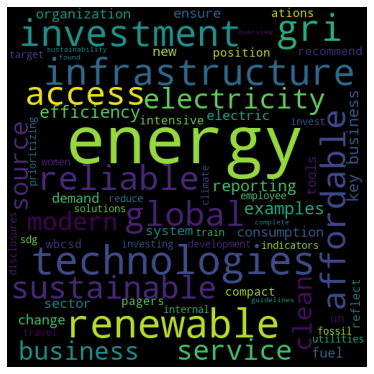

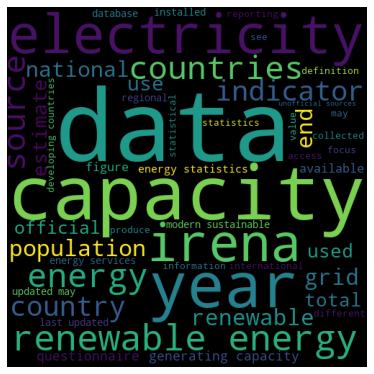

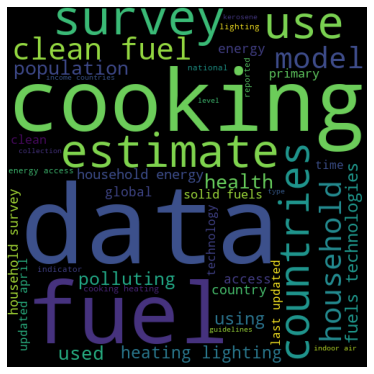

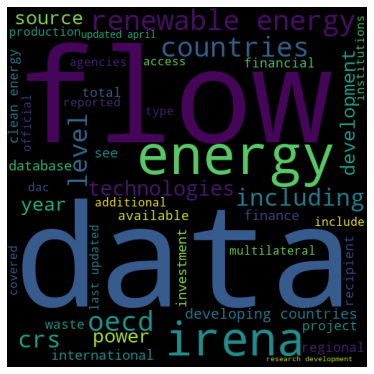

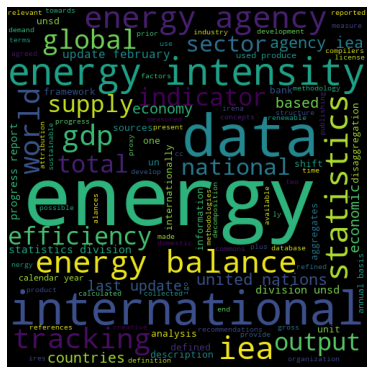

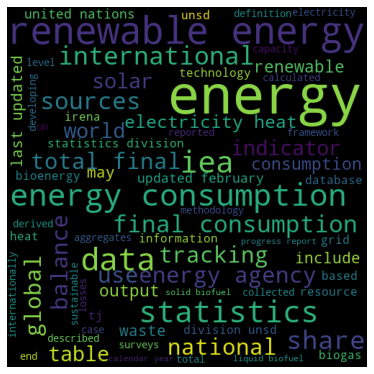

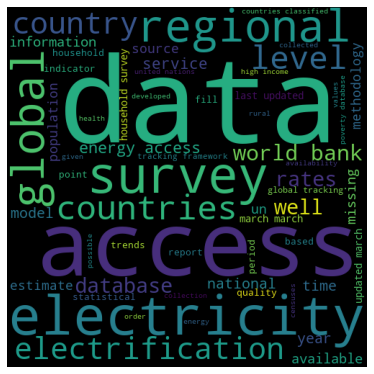

In [ ]:
# Python program to generate WordCloud 

# importing all necessery modules 
from wordcloud import WordCloud, STOPWORDS 
import matplotlib.pyplot as plt

# do wordart for ALL pdfs for frequency only

# iterate through list of lists where each list contains a long string
for pdf in mypdfs:
    wordcloud = WordCloud(width = 500, height = 500, 
                      background_color ='black',
                      min_font_size = 10).generate(pdf) 

    # plot the WordCloud image
    plt.figure(figsize = (8, 5), facecolor = None) 
    plt.imshow(wordcloud) 
    plt.axis("off") 
    plt.tight_layout(pad = 0) 

plt.show()

## Visualation Continued
These word clouds allow the data to be better understood but are currently per PDF, this can be improved by creating a single Word Cloud that takes into account all unqiue words across all the documents. This is given below, it should be noted that this one is a lot larger due to their being more words than previous word clouds. This leads to a small bias as certain words, such as energy, appear in every pdf, this therefore makes other words look like they're less used.

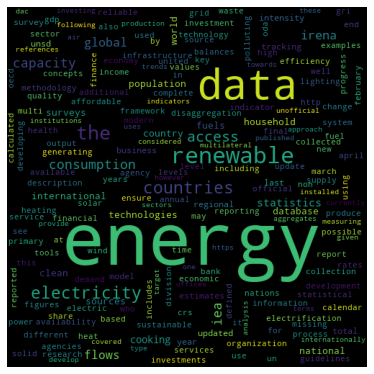

In [ ]:

# do wordart for only unique words in tfidf

# declare a dict to hold sum values for each col (k:col, v:sum)
d = {}
for col in df_tfidf_pdfs:
    d[col] = df_tfidf_pdfs[col].sum()
    
# Generate wordcloud
# relative_scaling adjusts importance of a frequency word
wordcloud = WordCloud(width=500,height=500,relative_scaling=1,
                      background_color ='black', min_font_size = 10, 
                      normalize_plurals=False).generate_from_frequencies(d)

# plot the WordCloud image
plt.figure(figsize = (8, 5), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.tight_layout(pad = 0) 

plt.show()

## Evaluating the Data Numerically
This data can also be broken down numerically by calculating the Recall, Precision and F-Score of the data, this will show how accurate the system is at getting the keywords when compared to the given keywords. The code for calculating this can be seen below.

In [ ]:
key_word_dict = [
    {
        "source": "SDG Compass",
        "section": "Key business themes addressed by this SDG",
        "URL": "https://sdgcompass.org/sdgs/sdg-7/",
        "key_words": ['Electricity access', 'Electricity availability', 'reliability', 'Renewable energy', 'Energy efficiency',
                     'Infrastructure investments', 'Environmental investments']
    },
    {
        "source":"SDG Compass",
        "section": "Goal 7 flyer",
        "URL": "https://sdgcompass.org/wp-content/uploads/2016/04/Goal_7.pdf",
        "key_words": ['Electricity access', 'Electricity availability', 'reliability', 'Renewable energy', 'Energy efficiency',
                     'Infrastructure investments', 'Environmental investments']
    },
    {
        ""
    }
]

# read text
# read text file of pdfs
#src3 = list(files.upload().values())[0]
#reader=open("drive/My Drive/SDG7/PDF_text_files.txt",'r')
    
# Read & print the entire file
#pdf_data = reader.read()

# manually store text files of pdfs
pdf_data = [['last', 'updated', 'march', 'march', 'goal', 'ensure', 'access', 'affordable', 'reliable', 'sustainable', 'modern', 'energy', 'target', 'by', 'ensure', 'universal', 'access', 'affordable', 'reliable', 'modern', 'energy', 'services', 'indicator', 'proportion', 'population', 'access', 'electricity', 'institutional', 'information', 'organization', 'world', 'bank', 'group', 'concepts', 'definitions', 'definition', 'proportion', 'population', 'access', 'electricity', 'percentage', 'population', 'access', 'electricity', 'ensure', 'access', 'affordable', 'reliable', 'sustainable', 'modern', 'energy', 'specifically', 'indicator', 'refers', 'p', 'roportion', 'population', 'access', 'electricity', 'this', 'expressed', 'percentage', 'figures', 'disaggregated', 'total', 'urban', 'rural', 'access', 'rates', 'per', 'country', 'well', 'un', 'regional', 'global', 'classifications', 'rationale', 'access', 'electricity', 'addresses', 'major', 'critical', 'issues', 'dimensions', 'sustainable', 'development', 'the', 'target', 'wide', 'range', 'social', 'economic', 'impacts', 'including', 'facilitating', 'development', 'income', 'generating', 'activities', 'lightening', 'burden', 'household', 'tasks', 'under', 'global', 'target', 'f', 'equal', 'access', 'energy', 'focuses', 'specifically', 'electricity', 'access', 'available', 'global', 'popula', 'tion', 'in', 'order', 'gain', 'clear', 'picture', 'access', 'rates', 'considered', 'primary', 'source', 'lighting', 'local', 'electricity', 'provider', 'solar', 'systems', 'mini', 'grids', 'stand', 'alone', 'systems', 's', 'ources', 'generators', 'candles', 'batteries', 'considered', 'due', 'limited', 'working', 'capacities', 'since', 'usually', 'kept', 'backup', 'sources', 'lighting', 'concepts', 'electricity', 'access', 'scenario', 'refers', 'proportion', 'population', 'considered', 'area', 'country', 'region', 'global', 'context', 'access', 'consistent', 'sources', 'electricity', 'urvey', 'data', 'well', 'census', 'data', 'it', 'also', 'incorporates', 'data', 'socio', 'economic', 'database', 'latin', 'america', 'caribbean', 'middle', 'east', 'north', 'africa', 'poverty', 'database', 'europe', 'central', 'asia', 'poverty', 'database', 'based', 'similar', 'surveys', 'at', 'time', 'analysis', 'global', 'electrification', 'database', 'contained', 'surveys', 'countries', 'excluding', 'surveys', 'high', 'income', 'countries', 'classified', 'united', 'nations', 'comments', 'limitations', 'last', 'updated', 'march', 'march', 'the', 'world', 'bank', 'aims', 'estimate', 'demand', 'side', 'access', 'rates', 'order', 'better', 'understand', 'access', 'levels', 'experienced', 'population', 'this', 'different', 'supply', 'side', 'access', 'rates', 'usually', 'provided', 'governments', 'ministries', 'etc', 'the', 'data', 'collecte', 'compiled', 'national', 'household', 'surveys', 'censuses', 'but', 'since', 'carried', 'infrequently', 'difficult', 'understand', 'ground', 'level', 'trends', 'short', 'term', 'periods', 'collecting', 'data', 'rural', 'areas', 'well', 'last', 'mile', 'connectivity', 'proble', 'ms', 'also', 'cause', 'errors', 'data', 'collection', 'could', 'skew', 'results', 'while', 'existing', 'global', 'household', 'survey', 'evidence', 'base', 'provides', 'good', 'starting', 'point', 'tracking', 'household', 'energy', 'access', 'also', 'presents', 'several', 'limitations', 'need', 'addressed', 'time', 'in', 'many', 'parts', 'world', 'presence', 'electricity', 'connection', 'household', 'necessarily', 'guarantee', 'energy', 'supplied', 'adequate', 'quality', 'reliability', 'affordable', 'co', 'st', 'would', 'desirable', 'fuller', 'information', 'critical', 'attributes', 'service', 'highlighted', 'substantial', 'progress', 'already', 'made', 'toward', 'developing', 'piloting', 'new', 'methodology', 'known', 'multi', 'tie', 'r', 'framework', 'measuring', 'energy', 'access', 'world', 'bank', 'able', 'capture', 'broader', 'dimensions', 'service', 'quality', 'would', 'make', 'possible', 'go', 'beyond', 'simple', 'measure', 'energy', 'access', 'refined', 'approach', 'recognizes', 'different', 'levels', 'energy', 'access', 'also', 'takes', 'account', 'affordability', 'reliability', 'energy', 'access', 'explicitly', 'referenced', 'language', 'the', 'methodology', 'multi', 'tier', 'framework', 'measuring', 'energy', 'access', 'already', 'published', 'based', 'broad', 'consultative', 'exercise', 'represents', 'consensus', 'view', 'across', 'numerous', 'household', 'survey', 'technical', 'working', 'group', 'regarding', 'mainstreaming', 'th', 'methodology', 'standardized', 'household', 'questionnaire', 'design', 'applied', 'every', 'three', 'years', 'low', 'income', 'countries', 'part', 'broader', 'sdg', 'monitoring', 'exercise', 'the', 'adoption', 'methodology', 'allow', 'time', 'refined', 'measurement', 'energy', 'access', 'making', 'possible', 'report', 'disaggregated', 'information', 'regarding', 'type', 'electricity', 'supply', 'grid', 'grid', 'capacity', 'electricity', 'supply', 'provided', 'watts', 'duration', 'service', 'daily', 'hours', 'evening', 'hours', 'reliability', 'service', 'terms', 'number', 'length', 'unplanned', 'service', 'interruptions', 'quality', 'service', 'terms', 'voltage', 'fluctuations', 'well', 'affordability', 'legality', 'service', 'another', 'advantage', 'approach', 'applied', 'measuring', 'energy', 'access', 'household', 'level', 'also', 'availability', 'support', 'enterprises', 'deliver', 'critical', 'community', 'services', 'health', 'education', 'methodological', 'challenges', 'asso', 'ciated', 'measurement', 'energy', 'access', 'fully', 'described', 'global', 'tracking', 'framework', 'chapter', 'section', 'page', 'esmap', 'methodology', 'computation', 'method', 'last', 'updated', 'march', 'march', 'data', 'well', 'census', 'data', 'it', 'also', 'incorporates', 'data', 'socio', 'economic', 'database', 'latin', 'america', 'caribbean', 'middle', 'east', 'north', 'africa', 'poverty', 'database', 'europe', 'central', 'asia', 'poverty', 'database', 'based', 'similar', 'surveys', 'at', 'time', 'analysis', 'global', 'electrification', 'database', 'contained', 'sur', 'veys', 'countries', 'excluding', 'surveys', 'high', 'income', 'countries', 'classified', 'united', 'nations', 'to', 'estimate', 'values', 'multilevel', 'nonparametric', 'modelling', 'approach', 'developed', 'world', 'health', 'organization', 'estimate', 'clean', 'fuel', 'usage', 'adapted', 'predict', 'electricity', 'access', 'used', 'fill', 'missing', 'data', 'points', 'time', 'period', 'where', 'data', 'available', 'access', 'estimates', 'weighted', 'population', 'multilevel', 'nonparametric', 'modelling', 'considers', 'hierarchical', 'structure', 'data', 'country', 'regional', 'levels', 'using', 'regional', 'classification', 'united', 'nations', 'the', 'mo', 'del', 'applied', 'countries', 'least', 'one', 'data', 'point', 'in', 'order', 'use', 'much', 'real', 'data', 'possible', 'results', 'based', 'real', 'survey', 'data', 'reported', 'original', 'form', 'years', 'available', 'the', 'statistical', 'model', 'used', 'fill', 'data', 'years', 'missing', 'conduct', 'global', 'regional', 'analyses', 'in', 'absence', 'survey', 'data', 'given', 'year', 'information', 'regional', 'trends', 'borrowed', 'the', 'difference', 'real', 'data', 'points', 'estimated', 'values', 'clearly', 'identified', 'database', 'd', 'h', 'igh', 'i', 'ncome', 'assumed', 'electrification', 'rates', 'percent', 'first', 'year', 'country', 'joined', 'category', 'in', 'present', 'report', 'avoid', 'electrification', 'trends', 'overshadow', 'electrification', 'efforts', 'since', 'model', 'run', 'twice', 'with', 'survey', 'data', 'assumptions', 'model', 'estimates', 'with', 'survey', 'data', 'assumptions', 'model', 'esti', 'mates', 'given', 'low', 'frequency', 'regional', 'distribution', 'surveys', 'several', 'countries', 'gaps', 'available', 'data', 'to', 'develop', 'historical', 'evolution', 'starting', 'point', 'electrification', 'rates', 'simple', 'modelling', 'approach', 'ad', 'opted', 'fill', 'missing', 'data', 'points', 'this', 'modelling', 'approach', 'allowed', 'estimation', 'electrification', 'rates', 'countries', 'time', 'periods', 'the', 'global', 'tracking', 'framework', 'report', 'referenced', 'provides', 'details', 'suggested', 'methodology', 'tracking', 'access', 'energy', 'chapter', 'section', 'page', 'disaggregation', 'electricity', 'access', 'rates', 'disaggregated', 'geographic', 'location', 'total', 'urban', 'rural', 'rates', 'countries', 'classified', 'developed', 'high', 'income', 'assumed', 'percen', 'first', 'year', 'added', 'category', 'disaggregation', 'access', 'electricity', 'rural', 'urban', 'place', 'residence', 'possible', 'countries', 'treatment', 'missing', 'values', 'at', 'country', 'level', 'given', 'low', 'frequency', 'regional', 'distribution', 'surveys', 'many', 'countries', 'gaps', 'data', 'availability', 'a', 'simple', 'modelling', 'approach', 'adopted', 'fill', 'missing', 'data', 'points', 'order', 'develop', 'historical', 'evolution', 'starting', 'point', 'electrification', 'rates', 'the', 'estimation', 'last', 'updated', 'march', 'march', 'conducted', 'using', 'model', 'region', 'country', 'time', 'variables', 'the', 'model', 'keeps', 'original', 'observation', 'data', 'available', 'the', 'statistical', 'model', 'us', 'ed', 'fill', 'data', 'years', 'missing', 'help', 'conduct', 'global', 'regional', 'analyses', 'in', 'absence', 'survey', 'data', 'given', 'year', 'information', 'regional', 'trends', 'borrowed', 'the', 'estimated', 'values', 'clearly', 'identified', 'estimate', 'database', 'at', 'regional', 'global', 'levels', 'values', 'regional', 'global', 'levels', 'calculated', 'incorporating', 'survey', 'data', 'along', 'model', 'estimated', 'values', 'substituting', 'missing', 'values', 'regional', 'global', 'classifications', 'based', 'un', 'm', 'series', 'statistical', 'use', 'regional', 'aggregates', 'global', 'coverage', 'available', 'world', 'bank', 'global', 'electrification', 'database', 'sources', 'discrepancies', 't', 'world', 'bank', 'database', 'compiles', 'electricity', 'usage', 'data', 'many', 'international', 'agencies', 'national', 'ministries', 'report', 'electricity', 'production', 'data', 'this', 'main', 'cause', 'data', 'discrepancie', 'the', 'quality', 'accuracy', 'population', 'data', 'also', 'lead', 'differences', 'assessing', 'electrification', 'meth', 'ods', 'guidance', 'available', 'countries', 'compilation', 'data', 'national', 'level', 'countries', 'generally', 'use', 'internationally', 'accepted', 'methods', 'conducting', 'censuses', 'national', 'surveys', 'there', 'level', 'disparity', 'countries', 'region', 'al', 'methodologies', 'efforts', 'harmonize', 'data', 'improving', 'answer', 'previous', 'question', 'quality', 'assurance', 'a', 'ulti', 'level', 'review', 'process', 'collaboration', 'industry', 'experts', 'national', 'statistical', 'offices', 'country', 'regional', 'experts', 'well', 'partnering', 'international', 'agencies', 'un', 'bodies', 'conducted', 'finalizing', 'data', 'before', 'finalizing', 'electricity', 'access', 'data', 'world', 'bank', 'team', 'contacts', 'relevant', 'national', 'statistical', 'offices', 'well', 'un', 'regional', 'commissions', 'asking', 'review', 'suggestions', 'prepared', 'figures', 'the', 'data', 'also', 'goes', 'multiple', 'rounds', 'vetting', 'process', 'internally', 'departments', 'the', 'relevant', 'links', 'provided', 'references', 'data', 'sources', 'last', 'updated', 'march', 'march', 'description', 'data', 'access', 'electricity', 'collected', 'household', 'surveys', 'censuses', 'tapping', 'wide', 'number', 'different', 'household', 'survey', 'types', 'including', 'multi', 'tier', 'framework', 'mtf', 'demographic', 'health', 'surveys', 'dhs', 'living', 'standards', 'measurement', 'surveys', 'lsms', 'multi', 'indicator', 'cluster', 'surveys', 'mics', 'world', 'health', 'survey', 'whs', 'nationally', 'developed', 'implemented', 'surveys', 'including', 'various', 'government', 'agencies', 'example', 'ministries', 'energy', 'utilities', 'the', 'world', 'bank', 'agency', 'taken', 'responsibility', 'compiling', 'meta', 'database', 'statistics', 'electricity', 'access', 'harvested', 'full', 'global', 'body', 'household', 'surveys', 'the', 'world', 'bank', 'elect', 'rification', 'database', 'covers', 'countries', 'period', 'updated', 'regularly', 'for', 'information', 'compiling', 'access', 'energy', 'data', 'see', 'global', 'tracking', 'framework', 'report', 'chapter', 'annex', 'page', 'reports', 'produced', 'international', 'agencies', 'un', 'world', 'bank', 'usaid', 'national', 'statistics', 'offices', 'well', 'country', 'censuses', 'used', 'collect', 'data', 'though', 'reports', 'might', 'directly', 'focus', 'e', 'nergy', 'access', 'tend', 'include', 'questions', 'regarding', 'access', 'electricity', 'collection', 'process', 'if', 'data', 'sources', 'information', 'electricity', 'access', 'collected', 'analysed', 'line', 'previous', 'trends', 'future', 'projections', 'country', 'data', 'validation', 'conducted', 'checking', 'figures', 'reflective', 'ground', 'level', 'scenario', 'well', 'line', 'country', 'populations', 'income', 'levels', 'electrification', 'programs', 'data', 'availability', 'description', 'data', 'currently', 'collected', 'countries', 'excluding', 'high', 'income', 'developed', 'countries', 'classified', 'united', 'nations', 'time', 'series', 'data', 'countries', 'compiled', 'period', 'though', 'gaps', 'accurate', 'data', 'availability', 'calendar', 'data', 'collection', 'the', 'next', 'round', 'data', 'collection', 'planned', 'second', 'half', 'data', 'release', 'the', 'annual', 'release', 'new', 'data', 'usually', 'month', 'may', 'last', 'updated', 'march', 'march', 'data', 'providers', 'it', 'varies', 'according', 'country', 'context', 'data', 'collected', 'national', 'statistics', 'agencies', 'well', 'international', 'agencies', 'un', 'world', 'bank', 'data', 'compilers', 'world', 'bank', 'group', 'references', 'url', 'https', 'development', 'indicators', 'https', 'references', 'multi', 'tier', 'fr', 'amework', 'measuring', 'energy', 'access', 'https', 'global', 'tracking', 'framework', 'report', 'http', 'global', 'tracking', 'framework', 'report', 'http', 'related', 'indicators', 'february'],]
print(len(pdf_data))
tmp = ''

# code for storing text file as list (not complete)
pdf_data_list_of_strings = []
for doc in pdf_data:

    for tok in doc:

        tmp = f'{tok} {tmp} '
    
    pdf_data_list_of_strings.append([tmp])
pdf_data_list_of_strings
len(pdf_data_list_of_strings)
from sklearn.feature_extraction.text import TfidfVectorizer #tfidf
import scipy
import numpy as np

class get_key_words():
    
    '''
    @params:
    corpus: list data type 
    
    purpose:
    do some TFIDF and n-gram methods to extract key_words
    ''' 
    
    # class variables
    c = None
    X = None
    k_words = []
    long_strings = []
    
    def __init__(self, corpus):
        
        # initilise variable
        self.c = corpus
        self.get_long_string()
        self.get_tfidf()
        
    def get_long_string(self):
        
        for doc in self.c:
            self.long_strings.append(doc)
       
    def get_tfidf(self):
        
        # get model call it vectoriser
        vectorizer = TfidfVectorizer()
        
        # transform corpus via model and store result of tfidf into variable named X
        # X is matrix of tfidf each row is a doc, each col is the tfidf weighting of the unique words
        self.X = scipy.sparse.csr_matrix.toarray(vectorizer.fit_transform(self.c))
        
        # get the feature names for each document, store those words to variable k_words
        self.k_words = vectorizer.get_feature_names()
        
        print(self.k_words)
      
    
    #Get key words given a specified document index in our corpus
    def get_words(self, doc_idx, num_key_words=3):
        key_words_idx = np.array(self.X.argsort()[doc_idx][-num_key_words:][::-1])
        key_words = np.array(self.k_words)[key_words_idx]
        return key_words

# pass pdf data into get_key_words class to run tfidf for key words extraction
PDF_DATA = [lst[0] for lst in pdf_data_list_of_strings]
obj =  get_key_words(PDF_DATA)

print(obj.X)
print(obj.get_words(4, num_key_words=10))


obj.X.argsort()[0]

print(obj.c[0])
print(len(obj.c[0]))


# from scikit learn tutorial docs

testing_corpus = obj.c[0]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(testing_corpus)
print(vectorizer.get_feature_names())

print(X.shape)

#from https://towardsdatascience.com/tf-idf-explained-and-python-sklearn-implementation-b020c5e83275

vectorizer=TfidfVectorizer()
tfIdf = vectorizer.fit_transform(testing_corpus)
df = pd.DataFrame(tfIdf[0].T.todense(), index=vectorizer.get_feature_names(), columns=["TF-IDF"])
df = df.sort_values('TF-IDF', ascending=False)
print (df.head(25))

vectorizer.get_feature_names()[0:10]

testing_corpus

1
['able', 'absence', 'accepted', 'access', 'according', 'account', 'accuracy', 'accurate', 'across', 'activities', 'ad', 'adapted', 'added', 'addressed', 'addresses', 'adequate', 'adopted', 'adoption', 'advantage', 'affordability', 'affordable', 'africa', 'agencies', 'agency', 'aggregates', 'aims', 'al', 'allow', 'allowed', 'alone', 'along', 'already', 'also', 'america', 'amework', 'analysed', 'analyses', 'analysis', 'annex', 'annual', 'another', 'answer', 'applied', 'approach', 'area', 'areas', 'asia', 'asking', 'assessing', 'asso', 'assumed', 'assumptions', 'assurance', 'at', 'attributes', 'availability', 'available', 'avoid', 'backup', 'bank', 'base', 'based', 'batteries', 'before', 'better', 'beyond', 'bodies', 'body', 'borrowed', 'broad', 'broader', 'burden', 'but', 'by', 'calculated', 'calendar', 'candles', 'capacities', 'capacity', 'capture', 'caribbean', 'carried', 'category', 'cause', 'census', 'censuses', 'central', 'challenges', 'chapter', 'checking', 'ciated', 'classificat

IndexError: ignored

Generated key_words = ['energy',
 'data',
 'renewable',
 'the',
 'countries',
 'electricity',
 'access',
 'capacity',
 'consumption',
 'iea',
 'irena',
 'global',
 'flows',
 'statistics',
 'cooking',
 'world',
 'technologies',
 'household',
 'clean',
 'surveys',
 'fuels',
 'national',
 'sources',
 'country',
 'international']

Gathered Zonodo Keywords['absorption heat pump','agrivoltaic',
 'air source heat pumps',
 'airborne wind turbine',
 'alcohol fuel',
 'algae bioreactor',
 'algae fuel',
 'alkaline anion exchange membrane fuel cell',
 'alkaline fuel cell',
 'alternative energy',
 'alternative fuel',
 'alternatives to car use',
 'aluminium recycling',
 'aluminium–air battery',
 'appliance recycling',
 'autonomous building',
 'bi-fuel vehicle',
 'biobased economy',
 'bioconversion',
 'biodegradable electronics',
 'bioenergy',
 'biofuel',
 'biogas',
 'biogasoline',
 'biological hydrogen production (algae)',
 'biomass briquettes',
 'blue carbon',
 'bottle recycling',
 'building insulation',
 'building performance',
 'cap and dividend',
 'carbon capture and utilisation',
 'carbon dioxide removal',
 'carbon dioxide scrubber',
 'carbon emission',
 'carbon farming',
 'carbon footprint',
 'carbon intensity',
 'carbon offset',
 'carbon pollution reduction scheme',
 'carbon sequestration',
 'carbon tax',
 'carbon-based fuel',
 'carbon-neutral fuel',
 'carbonzero programme',
 'carpool',
 'carsharing',
 'certification for sustainable transportation',
 'charcoal',
 'charging station',
 'chicago climate action plan',
 'chinese national carbon trading scheme',
 'clean energy',
 'clean fuel',
 'clean technology',
 'cleaner production',
 'climate capitalism',
 'co2 emission',
 'co2balance',
 'coal consumption',
 'coalbed methane',
 'combined gas and steam',
 'combined nuclear and steam propulsion',
 'combined steam and gas',
 'common external power supply',
 'compressed air car',
 'compressed-air vehicle',
 'double glazing',
 'ecohouse',
 'electric energy',
 'electric motor',
 'electric power',
 'electric power distribution',
 'electrical energy',
 'electrical grid',
 'electrical power',
 'electricity',
 'electricity consumption',
 'electricity cost',
 'electricity generation',
 'electricity market',
 'electrofuel',
 'emissions trading',
 'energy',
 'energy audit',
 'energy conservation',
 'energy consumption',
 'energy conversion efficiency',
 'energy cost',
 'energy crop',
 'energy demand',
 'energy efficiency',
 'energy harvesting',
 'energy intensity',
 'energy management',
 'energy performance',
 'energy poverty',
 'energy productivity',
 'energy research',
 'energy transition',
 'energy usage',
 'energy use',
 'fluorescent lamp recycling',
 'formic acid fuel cell',
 'fossil fuel phase-out',
 'fuel consumption',
 'fuel efficiency',
 'fuel poverty',
 'fusion power',
 'geothermal desalination',
 'geothermal energy',
 'geothermal heat pump',
 'geothermal heating',
 'geothermal power',
 'german climate action plan 2050',
 'green energy',
 'green technologies',
 'greenhouse debt',
 'greenhouse gas',
 'ground heat exchanger',
 'hybrid power',
 'hydrogen fuel',
 'hydrogen station',
 'hydrogen technologies',
 'hydrogen vehicle',
 'infrastructure upgrade',
 'less energy',
 'liquid nitrogen engine',
 'lithium economy',
 'lithium–air battery',
 'low carbon communities',
 'low-carbon economy',
 'magnesium battery',
 'meat tax',
 'metal–air electrochemical cell',
 'microbiofuel',
 'natural gas storage',
 'nuclear power',
 'nuclear safety and security',
 'osmotic power',
 'pellet fuel',
 'pellet stove',
 'phase-out of fossil fuel vehicles',
 'photobioreactor',
 'photovoltaic',
 'photovoltaic power station',
 'photovoltaic system',
 'plastic recycling',
 'power consumption',
 'public schemes for energy efficient refurbishment',
 'renewable electricity',
 'renewable energy',
 'renewable fuels',
 'renewable generation',
 'renewable natural gas',
 'renewable power',
 'renewable resources',
 'renewable sources',
 'reversed electrodialysis',
 'seaweed fuel',
 'smart grid',
 'solar air conditioning',
 'solar air heat',
 'solar bus',
 'solar car',
 'solar cell',
 'solar charger',
 'solar cooker',
 'solar energy',
 'solar panel',
 'solar power',
 'solar roadway',
 'solar thermal collector',
 'solar updraft tower',
 'solar vehicle',
 'solar water heating',
 'solar-powered refrigerator',
 'sustainable aviation fuel',
 'sustainable electronic',
 'sustainable energy',
 'sustainable power',
 'sustainable transport',
 'synthetic fuel',
 'technology upgrade',
 'thermal energy',
 'thermoelectric generator',
 'thermophotonics',
 'thermophotovoltaic',
 'tidal energy',
 'tidal stream generator',
 'tide mill',
 'vehicle-to-grid',
 'waste heat recovery unit',
 'water heat recycling',
 'wave energy',
 'wave power',
 'wind energy',
 'wind farm',
 'wind farms',
 'wind generation',
 'wind power',
 'wind resource',
 'windbelt',
 'windpump',
 'wood energy']

Recall=13%  Didn't get all the keyowrds

Precision=100% All words gotten were keywords and none were incorrect

F-Score=23% Quite Low but not terrible

Can be improved easily by giving it a larger dataset of PDFs